In [486]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [487]:
# Confirm which builds are active before running numerical code
print("torch:", torch.__version__)
print("numpy:", np.__version__)

torch: 2.11.0+cu130
numpy: 2.2.6


In [488]:
# Helper: draw 2D vectors from the origin; used throughout to visualise tensor operations
def plot_2d_vectors(vectors):
    ax = plt.axes()
    for vec in vectors:
        ax.arrow(0, 0, *vec["vector"], head_width=0.05, color=vec["color"], head_length=0.1)
        plt.text(*(vec["vector"] + 0.1), vec["name"])
    plt.ylim(-2, 2)
    plt.xlim(-2, 2)

In [489]:
# Helper: render a 2D tensor as a styled DataFrame — colour-coded by value, no index labels
# IPython.display.display() is needed to render inside a function call, not just as the last cell expression
from IPython.display import display

def display_matrix(tensor, title="", cmap="YlGn"):
    if title:
        print(title)
    df = pd.DataFrame(tensor.numpy())
    styled = (df.style
                .background_gradient(cmap=cmap)
                .hide(axis="index")
                .hide(axis="columns"))
    display(styled)

In [490]:
# torch.tensor() infers dtype from the input: integer list → torch.int64 (LongTensor)
tensor_1 = torch.tensor([0, 1, 2, 3, 4])
print("dtype:", tensor_1.dtype)
print("type:", tensor_1.type())
print("Python type:", type(tensor_1))

dtype: torch.int64
type: torch.LongTensor
Python type: <class 'torch.Tensor'>


In [491]:
# Float literals in the list → torch.float32 (FloatTensor)
tensor_2 = torch.tensor([0.0, 1.0, 2.0, 3.0, 4.0])
print("dtype:", tensor_2.dtype)
print("type:", tensor_2.type())

dtype: torch.float32
type: torch.FloatTensor


In [492]:
# Override inferred dtype at construction time — floats stored as int64, fractional parts truncated
tensor_3 = torch.tensor([0.0, 1.0, 2.0, 3.0, 4.0], dtype=torch.int64)
print("dtype:", tensor_3.dtype)
print("type:", tensor_3.type())

dtype: torch.int64
type: torch.LongTensor


In [493]:
# torch.FloatTensor() forces float32 regardless of input value types
tensor_4 = torch.FloatTensor([0, 1, 2, 3, 4])
print("type:", tensor_4.type())

type: torch.FloatTensor


In [494]:
# Cast an existing tensor to another dtype using .type()
tensor_5 = torch.tensor([0, 1, 2, 3, 4])
tensor_4 = tensor_5.type(torch.FloatTensor)
print("type:", tensor_4.type())

type: torch.FloatTensor


In [495]:
# .size() returns a tuple-like Size object; .ndimension() is the number of axes (rank)
print("size:", tensor_4.size())
print("ndimension:", tensor_4.ndimension())

size: torch.Size([5])
ndimension: 1


In [496]:
# .view() reshapes without copying data; total element count must stay constant
# -1 tells PyTorch to infer that dimension automatically
col_vector = tensor_4.view(5, 1)
print("original:", tensor_4.size())
print("view(5,1):", col_vector.size())

col_vector_auto = tensor_4.view(-1, 1)
print("view(-1,1):", col_vector_auto.size())

original: torch.Size([5])
view(5,1): torch.Size([5, 1])
view(-1,1): torch.Size([5, 1])


In [497]:
# torch.reshape() is the safer alternative to .view() — same semantics but works on non-contiguous tensors
# Returns a view when possible, a copy when not
reshaped = torch.reshape(tensor_4, (5, 1))
print("reshape(5,1):", reshaped.size())

reshaped_auto = torch.reshape(tensor_4, (-1, 1))
print("reshape(-1,1):", reshaped_auto.size())

reshape(5,1): torch.Size([5, 1])
reshape(-1,1): torch.Size([5, 1])


In [498]:
# Step-slicing skips elements, so the result has gaps in memory — it is non-contiguous
tensor_6 = torch.arange(6)
tensor_7 = tensor_6[::2]   # [0, 2, 4] — stride is 2, not 1
print("original contiguous:", tensor_6.is_contiguous())
print("strided contiguous: ", tensor_7.is_contiguous())

# .view() requires contiguous memory and will raise RuntimeError when shape change needs different strides
# .contiguous() forces a copy that is sequential in memory, making .view() safe
print("contiguous + view:", tensor_7.contiguous().view(3))

# torch.reshape() calls .contiguous() internally when needed — no manual step required
print("reshape:          ", torch.reshape(tensor_7, (3,)))

original contiguous: True
strided contiguous:  False
contiguous + view: tensor([0, 2, 4])
reshape:           tensor([0, 2, 4])


In [499]:
# torch.from_numpy() and .numpy() share the same memory — no copy is made
# Mutating the numpy array changes the tensor and vice versa
original_array = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
tensor_8 = torch.from_numpy(original_array)
same_original_array = tensor_8.numpy()

original_array[:] = 0
print("--- shared memory demo ---")
print("original_array after zeroing:  ", original_array)
print("tensor_8 (shares memory):      ", tensor_8)
print("same_original_array (alias):   ", same_original_array)

# To break the shared-memory link, use .clone() on the tensor or torch.tensor() instead of from_numpy()
original_array = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
tensor_8 = torch.from_numpy(original_array).clone()
cloned_array = tensor_8.numpy()

original_array[:] = 0
print("\n--- clone demo ---")
print("original_array after zeroing:  ", original_array)
print("tensor_8 (independent clone):  ", tensor_8)
print("cloned_array (from clone):     ", cloned_array)

--- shared memory demo ---
original_array after zeroing:   [0. 0. 0. 0. 0.]
tensor_8 (shares memory):       tensor([0., 0., 0., 0., 0.], dtype=torch.float64)
same_original_array (alias):    [0. 0. 0. 0. 0.]

--- clone demo ---
original_array after zeroing:   [0. 0. 0. 0. 0.]
tensor_8 (independent clone):   tensor([0., 1., 2., 3., 4.], dtype=torch.float64)
cloned_array (from clone):      [0. 1. 2. 3. 4.]


In [500]:
# Pandas Series → tensor via .values (which returns the underlying numpy array)
pandas_series = pd.Series([0.1, 2, 0.3, 10.1])
tensor_9 = torch.from_numpy(pandas_series.values)
print("tensor:", tensor_9)
print("dtype:", tensor_9.dtype)

tensor: tensor([ 0.1000,  2.0000,  0.3000, 10.1000], dtype=torch.float64)
dtype: torch.float64


In [501]:
# .item() extracts a plain Python scalar from a 0-d or single-element view — needed for logging and conditionals
# .tolist() converts the whole tensor to a nested Python list
tensor_10 = torch.tensor([0, 1, 2, 3])
print("item at [0]:", tensor_10[0].item(), "  tensor value:", tensor_10[0])
print("tolist:", tensor_10.tolist())

item at [0]: 0   tensor value: tensor(0)
tolist: [0, 1, 2, 3]


In [502]:
# 0-based indexing; tensor_11[5] on a length-5 tensor raises IndexError
tensor_11 = torch.tensor([0, 1, 2, 3, 4])
for i in range(5):
    print(f"index {i}:", tensor_11[i])

index 0: tensor(0)
index 1: tensor(1)
index 2: tensor(2)
index 3: tensor(3)
index 4: tensor(4)


In [503]:
# Tensors are mutable — element assignment modifies the tensor in-place
tensor_12 = torch.tensor([20, 1, 2, 3, 4])
tensor_12[0] = 100
tensor_12[4] = 0
print("after mutation:", tensor_12)

after mutation: tensor([100,   1,   2,   3,   0])


In [504]:
# Slice syntax [start:stop] — stop is exclusive, same as Python lists
print("original:", tensor_12)
print("slice [1:4]:", tensor_12[1:4])

# Assign a tensor to a slice — lengths must match
tensor_12[3:5] = torch.tensor([300, 400])
print("after slice assignment:", tensor_12)

original: tensor([100,   1,   2,   3,   0])
slice [1:4]: tensor([1, 2, 3])
after slice assignment: tensor([100,   1,   2, 300, 400])


In [505]:
# Fancy indexing: pass a list of indices to read or write non-contiguous elements
print("elements at [3,4]:", tensor_12[[3, 4]])

# Assign a single scalar to all selected positions at once
tensor_12[[1, 3]] = 100000
print("after fancy assignment:", tensor_12)

elements at [3,4]: tensor([300, 400])
after fancy assignment: tensor([   100, 100000,      2, 100000,    400])


In [506]:
# .mean() and .std() reduce the entire tensor to a scalar — useful for monitoring training metrics
tensor_13 = torch.tensor([1.0, -1.0, 1.0, -1.0])
print("mean:", tensor_13.mean())
print("std:", tensor_13.std())

mean: tensor(0.)
std: tensor(1.1547)


In [507]:
# .max() and .min() return the extreme value, not its index; duplicates are handled silently
tensor_14 = torch.tensor([1, 1, 3, 5, 5])
print("max:", tensor_14.max())
print("min:", tensor_14.min())

max: tensor(5)
min: tensor(1)


In [508]:
# torch.sin() is element-wise — output shape matches input shape, unlike aggregation methods
tensor_15 = torch.tensor([0, np.pi / 2, np.pi])
print("sin:", torch.sin(tensor_15))

sin: tensor([ 0.0000e+00,  1.0000e+00, -8.7423e-08])


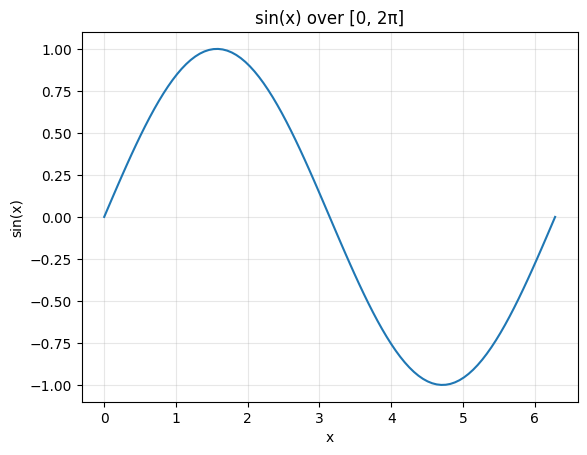

In [509]:
# torch.linspace(start, end, steps) generates evenly spaced values — the standard way to build plot axes
x = torch.linspace(0, 2 * np.pi, 100)
y = torch.sin(x)

# .numpy() is required because Matplotlib cannot consume tensors directly
plt.plot(x.numpy(), y.numpy())
plt.title("sin(x) over [0, 2π]")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.grid(alpha=0.3)
plt.show()

u + v: tensor([1, 1])


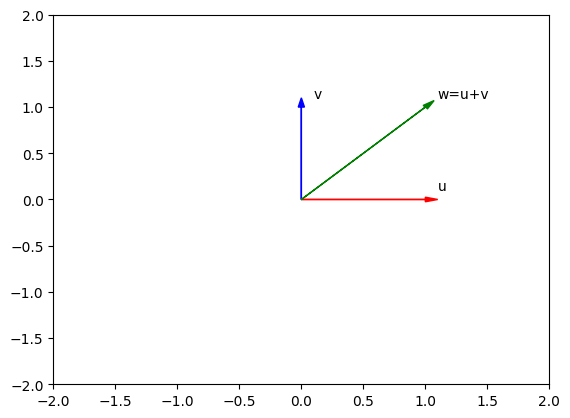

In [510]:
# + is element-wise addition; tensors must have the same shape
u = torch.tensor([1, 0])
v = torch.tensor([0, 1])
w = u + v
print("u + v:", w)

plot_2d_vectors([
    {"vector": u.numpy(), "name": "u", "color": "r"},
    {"vector": v.numpy(), "name": "v", "color": "b"},
    {"vector": w.numpy(), "name": "w=u+v", "color": "g"},
])

In [511]:
# Adding a scalar broadcasts it to every element — same result as adding a constant tensor
u = torch.tensor([1, 2, 3, -1])
print("u + 1:", u + 1)

u + 1: tensor([2, 3, 4, 0])


In [512]:
# * is element-wise (Hadamard) multiplication, not matrix multiplication
u = torch.tensor([1, 2])
v = torch.tensor([3, 2])
print("2 * u:", 2 * u)
print("u * v:", u * v)

2 * u: tensor([2, 4])
u * v: tensor([3, 4])


In [513]:
# torch.dot() computes the inner product: sum of element-wise products
# For u=[1,2], v=[3,2]: 1*3 + 2*2 = 7
u = torch.tensor([1, 2])
v = torch.tensor([3, 2])
print("dot(u, v):", torch.dot(u, v))

dot(u, v): tensor(7)


In [514]:
# torch.tensor() accepts nested lists to create 2D tensors — same syntax as 1D
tensor_16 = torch.tensor([[11, 12, 13], [21, 22, 23], [31, 32, 33]])
print("tensor:", tensor_16)
print("ndimension:", tensor_16.ndimension())
print("shape:", tensor_16.shape)
print("size:", tensor_16.size())
# numel() returns the total number of elements across all dimensions
print("numel:", tensor_16.numel())
display_matrix(tensor_16)

tensor: tensor([[11, 12, 13],
        [21, 22, 23],
        [31, 32, 33]])
ndimension: 2
shape: torch.Size([3, 3])
size: torch.Size([3, 3])
numel: 9


11,12,13
21,22,23
31,32,33


In [515]:
# .numpy() and from_numpy() work identically in 2D — shared memory still applies
numpy_matrix = tensor_16.numpy()
print("tensor → numpy:", numpy_matrix, "  dtype:", numpy_matrix.dtype)

tensor_17 = torch.from_numpy(numpy_matrix)
print("numpy → tensor:", tensor_17, "  dtype:", tensor_17.dtype)

tensor → numpy: [[11 12 13]
 [21 22 23]
 [31 32 33]]   dtype: int64
numpy → tensor: tensor([[11, 12, 13],
        [21, 22, 23],
        [31, 32, 33]])   dtype: torch.int64


In [516]:
# DataFrame.values exposes the underlying numpy array — shape matches (rows × columns)
df = pd.DataFrame({'a': [11, 21, 31], 'b': [12, 22, 312]})
tensor_18 = torch.from_numpy(df.values)
print("DataFrame values:", df.values, "  dtype:", df.values.dtype)
print("tensor:", tensor_18, "  dtype:", tensor_18.dtype)

DataFrame values: [[ 11  12]
 [ 21  22]
 [ 31 312]]   dtype: int64
tensor: tensor([[ 11,  12],
        [ 21,  22],
        [ 31, 312]])   dtype: torch.int64


In [517]:
# [row, col] and [row][col] both reach the same element — [row, col] is preferred (single operation)
tensor_19 = torch.tensor([[11, 12, 13], [21, 22, 23], [31, 32, 33]])
print("row 1, col 2 via [1, 2]: ", tensor_19[1, 2])
print("row 1, col 2 via [1][2]: ", tensor_19[1][2])

row 1, col 2 via [1, 2]:  tensor(23)
row 1, col 2 via [1][2]:  tensor(23)


In [518]:
# Row + column slicing must be in a single bracket [row_slice, col_index]
# Chained brackets [row_slice][col_index] applies the second index to the rows of the slice result, not columns
print("row 0, cols 0:2 via [0, 0:2]:", tensor_19[0, 0:2])
print("row 0, cols 0:2 via [0][0:2]:", tensor_19[0][0:2])

# [1:3] returns a 2-row sub-tensor; [1] on that picks its second row — not column 1
print("\ntensor_19[1:3]:      ", tensor_19[1:3])
print("tensor_19[1:3][1]:   ", tensor_19[1:3][1])   # this is row 3, not column 1
print("tensor_19[1:3, 2]:   ", tensor_19[1:3, 2])   # correct: rows 1-2, column 2

row 0, cols 0:2 via [0, 0:2]: tensor([11, 12])
row 0, cols 0:2 via [0][0:2]: tensor([11, 12])

tensor_19[1:3]:       tensor([[21, 22, 23],
        [31, 32, 33]])
tensor_19[1:3][1]:    tensor([31, 32, 33])
tensor_19[1:3, 2]:    tensor([23, 33])


In [519]:
# 2D element-wise addition — identical to matrix addition; shapes must match exactly
X = torch.tensor([[1, 0], [0, 1]])
Y = torch.tensor([[2, 1], [1, 2]])
print("X + Y:", X + Y)

X + Y: tensor([[3, 1],
        [1, 3]])


In [520]:
# Scalar multiplication broadcasts to every element — same rule as 1D
print("2 * Y:", 2 * Y)

# * is element-wise (Hadamard) multiplication — not matrix multiplication
print("X * Y:", X * Y)

2 * Y: tensor([[4, 2],
        [2, 4]])
X * Y: tensor([[2, 0],
        [0, 2]])


In [521]:
# torch.mm() performs true matrix multiplication — inner dimensions must match (cols of A == rows of B)
# A is 2×3, B is 3×2 → result is 2×2
A = torch.tensor([[0, 1, 1], [1, 0, 1]])
B = torch.tensor([[1, 1], [1, 1], [-1, 1]])
print("A @ B:", torch.mm(A, B))

A @ B: tensor([[0, 2],
        [0, 2]])


In [522]:
# * (element-wise) requires identical shapes — X and Y are both 2×2, so this works
# torch.mm(X, Y) also works here because X and Y are square: cols of X (2) == rows of Y (2)
X = torch.tensor([[1, 0], [0, 1]])
Y = torch.tensor([[2, 1], [1, 2]])
X_times_Y = X * Y
print(X_times_Y)

# torch.mm(A, B) works: A is 2×3, B is 3×2 — inner dimensions match (3 == 3), result is 2×2
# A * B would fail: shapes 2×3 and 3×2 are not identical, so element-wise multiply is undefined
A = torch.tensor([[0, 1, 1], [1, 0, 1]])
B = torch.tensor([[1, 1], [1, 1], [-1, 1]])
A_times_B = torch.mm(A, B)
print(A_times_B)

tensor([[2, 0],
        [0, 2]])
tensor([[0, 2],
        [0, 2]])
